In [13]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [14]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

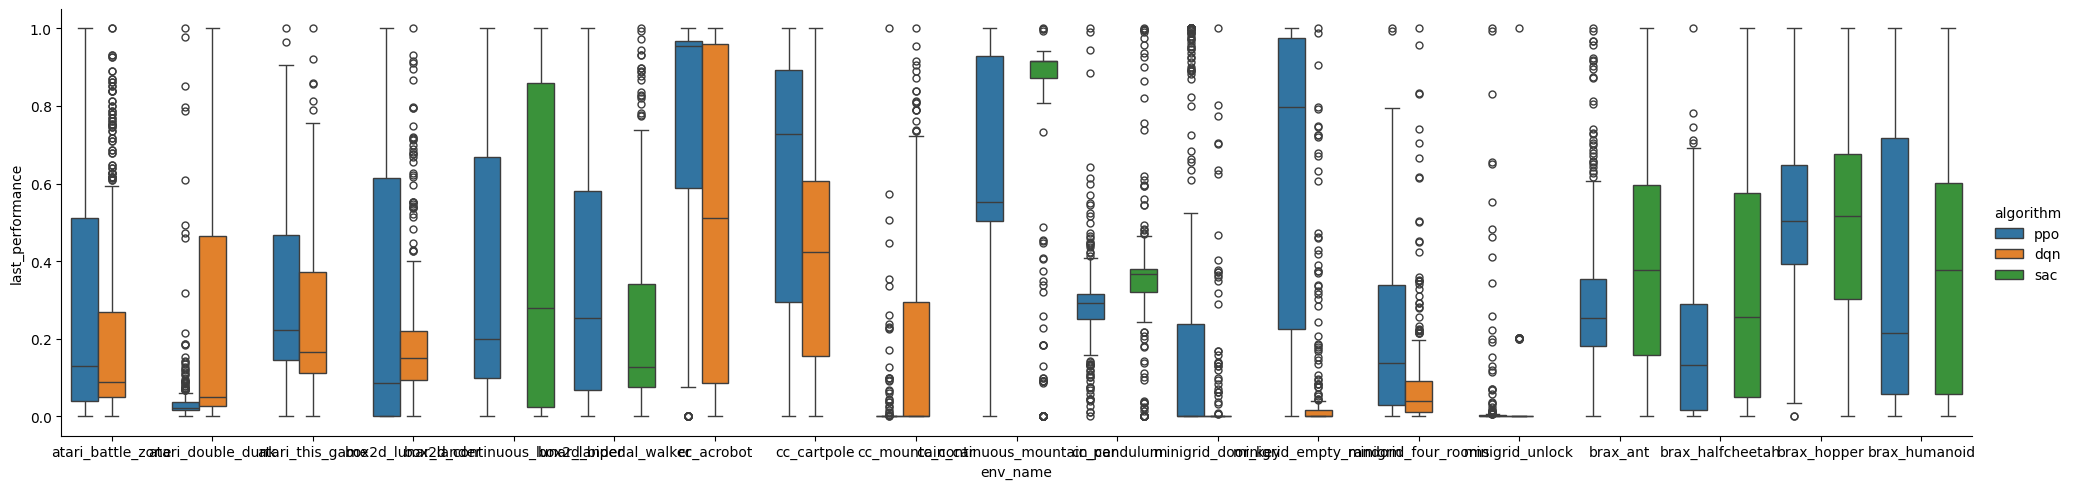

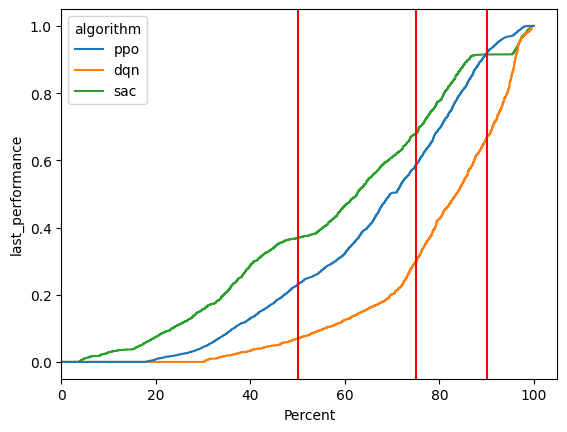

In [15]:
sns.catplot(data=data, x="env_name", y="last_performance", hue="algorithm", kind="box", aspect=4)
plt.figure()
data.dropna(subset=["last_performance"], inplace=True)
data.drop_duplicates(subset=["env_name", "algorithm", "config_id"], inplace=True)
sns.ecdfplot(data=data, y="last_performance", hue="algorithm", stat="percent")
plt.axvline(50, color='red')
plt.axvline(75, color='red')
plt.axvline(90, color='red')
#plt.axhline(0.37, xmax=0.48, color='green')
#plt.axhline(0.69, xmax=0.71, color='green')
#plt.axhline(0.92, xmax=0.86, color='green', alpha=0.5)
#plt.axhline(0.23, xmax=0.48, color='blue')
#plt.axhline(0.57, xmax=0.71, color='blue')
#plt.axhline(0.92, xmax=0.86, color='blue', alpha=0.5)
#plt.axhline(0.07, xmax=0.48, color='orange')
#plt.axhline(0.3, xmax=0.71, color='orange')
#plt.axhline(0.67, xmax=0.86, color='orange')

In [16]:
def get_tunability(df, percentile):
    tunabilities = []
    algos = []
    envs = []
    for env in df["env_name"].unique():
        for algo in df["algorithm"].unique():
            subset = df[(df["env_name"]==env) & (df["algorithm"]==algo)]
            threshold = subset["last_performance"].quantile(percentile)
            tunability = subset["last_performance"].max() - threshold
            tunabilities.append(tunability)
            algos.append(algo)
            envs.append(env)
    tunabilities = pd.DataFrame({
        "env_name": envs,
        "algorithm": algos,
        "tunability": tunabilities
    })
    return tunabilities

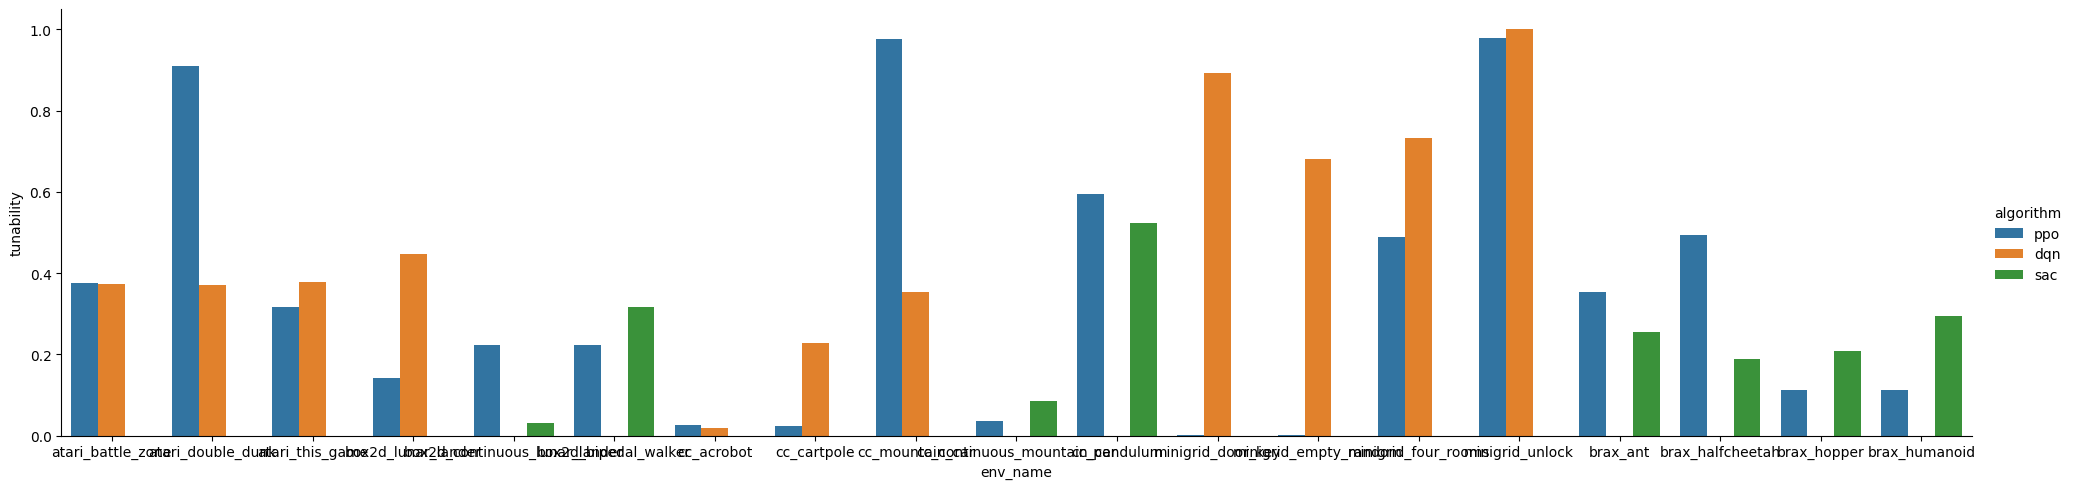

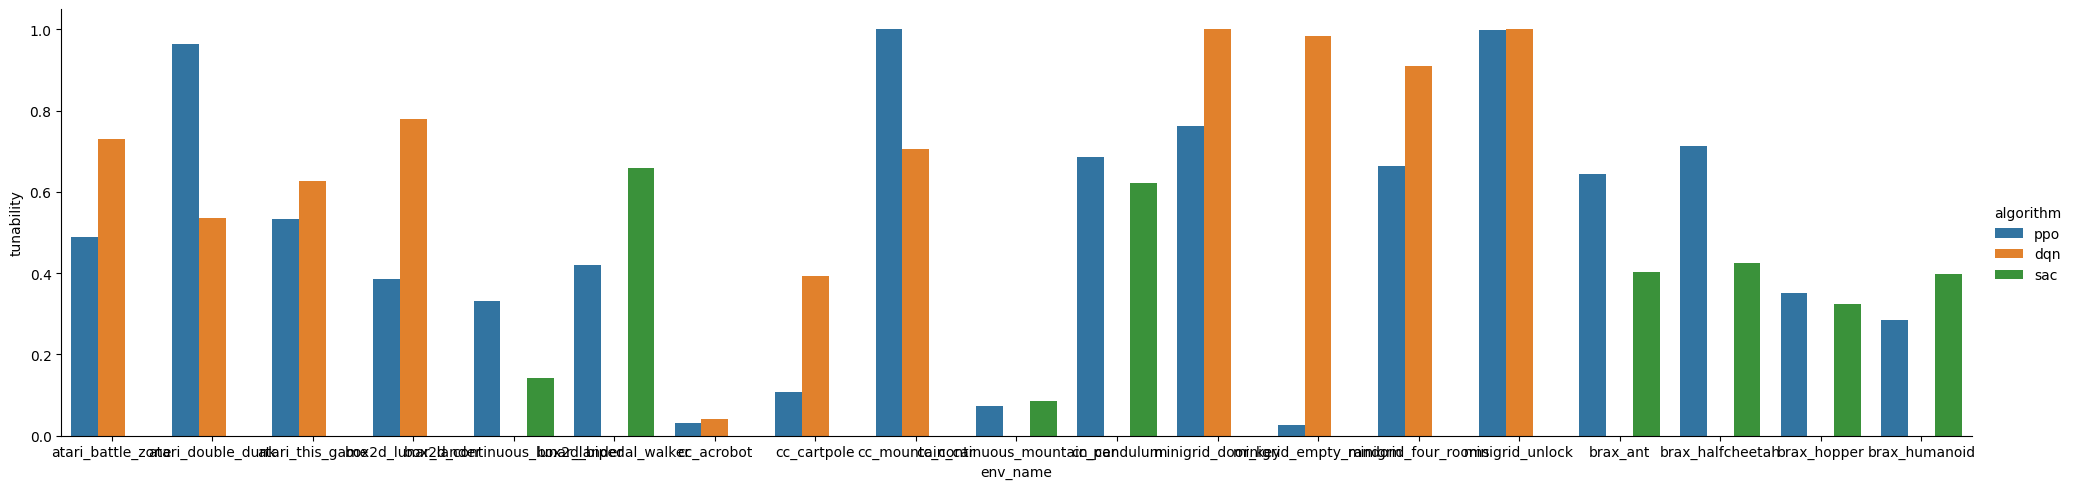

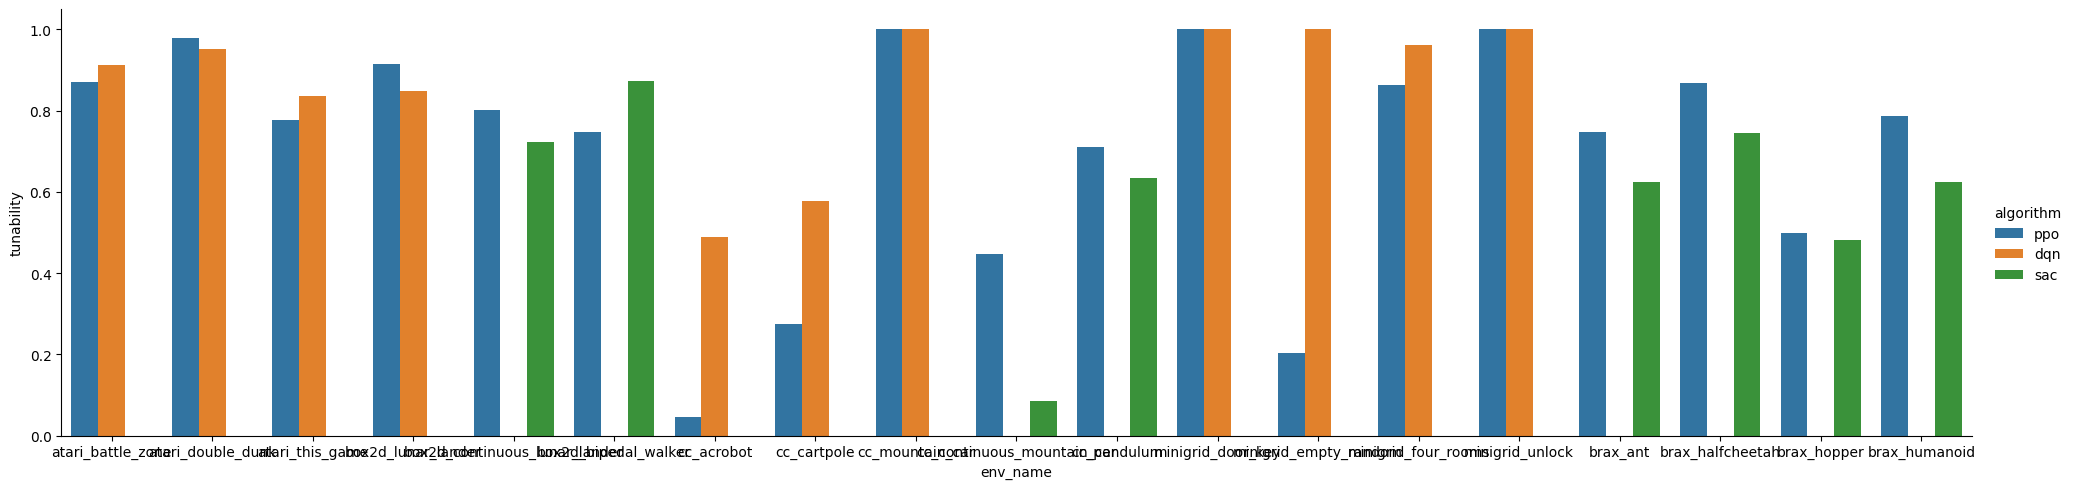

In [17]:
tune_09 = get_tunability(data, 0.9)
tune_075 = get_tunability(data, 0.75)
tune_50 = get_tunability(data, 0.5)
tune_95 = get_tunability(data, 0.95)
tune_85 = get_tunability(data, 0.85)
tune_80 = get_tunability(data, 0.8)
tune_70 = get_tunability(data, 0.7)
tune_65 = get_tunability(data, 0.65)
tune_60 = get_tunability(data, 0.6)
tune_55 = get_tunability(data, 0.55)
tune_45 = get_tunability(data, 0.45)
tune_40 = get_tunability(data, 0.4)
tune_35 = get_tunability(data, 0.35)
tune_30 = get_tunability(data, 0.3)
tune_25 = get_tunability(data, 0.25)
tune_20 = get_tunability(data, 0.2)
tune_15 = get_tunability(data, 0.15)
tune_10 = get_tunability(data, 0.1)
tune_05 = get_tunability(data, 0.05)

sns.catplot(data=tune_09, x="env_name", y="tunability", hue="algorithm", kind="bar", aspect=4)
sns.catplot(data=tune_075, x="env_name", y="tunability", hue="algorithm", kind="bar", aspect=4)
sns.catplot(data=tune_50, x="env_name", y="tunability", hue="algorithm", kind="bar", aspect=4)

<Axes: xlabel='algorithm', ylabel='tunability'>

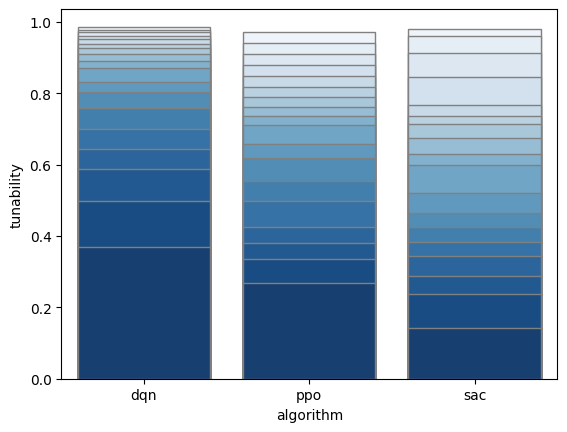

In [18]:
mean_tunabilites_09 = tune_09.groupby("algorithm")["tunability"].mean()
mean_tunabilites_075 = tune_075.groupby("algorithm")["tunability"].mean()
mean_tunabilites_05 = tune_50.groupby("algorithm")["tunability"].mean()
mean_tunabilites_005 = tune_05.groupby("algorithm")["tunability"].mean()
mean_tunabilites_10 = tune_10.groupby("algorithm")["tunability"].mean()
mean_tunabilites_15 = tune_15.groupby("algorithm")["tunability"].mean()
mean_tunabilites_20 = tune_20.groupby("algorithm")["tunability"].mean()
mean_tunabilites_25 = tune_25.groupby("algorithm")["tunability"].mean()
mean_tunabilites_30 = tune_30.groupby("algorithm")["tunability"].mean()
mean_tunabilites_35 = tune_35.groupby("algorithm")["tunability"].mean()
mean_tunabilites_40 = tune_40.groupby("algorithm")["tunability"].mean()
mean_tunabilites_45 = tune_45.groupby("algorithm")["tunability"].mean()
mean_tunabilites_55 = tune_55.groupby("algorithm")["tunability"].mean()
mean_tunabilites_60 = tune_60.groupby("algorithm")["tunability"].mean()
mean_tunabilites_65 = tune_65.groupby("algorithm")["tunability"].mean()
mean_tunabilites_70 = tune_70.groupby("algorithm")["tunability"].mean()
mean_tunabilites_80 = tune_80.groupby("algorithm")["tunability"].mean()
mean_tunabilites_85 = tune_85.groupby("algorithm")["tunability"].mean()
mean_tunabilites_95 = tune_95.groupby("algorithm")["tunability"].mean()
mean_tunabilites_09 = mean_tunabilites_09.reset_index()
mean_tunabilites_075 = mean_tunabilites_075.reset_index()
mean_tunabilites_05 = mean_tunabilites_05.reset_index()
mean_tunabilites_005 = mean_tunabilites_005.reset_index()
mean_tunabilites_10 = mean_tunabilites_10.reset_index()
mean_tunabilites_15 = mean_tunabilites_15.reset_index()
mean_tunabilites_20 = mean_tunabilites_20.reset_index()
mean_tunabilites_25 = mean_tunabilites_25.reset_index()
mean_tunabilites_30 = mean_tunabilites_30.reset_index()
mean_tunabilites_35 = mean_tunabilites_35.reset_index()
mean_tunabilites_40 = mean_tunabilites_40.reset_index()
mean_tunabilites_45 = mean_tunabilites_45.reset_index()
mean_tunabilites_55 = mean_tunabilites_55.reset_index()
mean_tunabilites_60 = mean_tunabilites_60.reset_index()
mean_tunabilites_65 = mean_tunabilites_65.reset_index()
mean_tunabilites_70 = mean_tunabilites_70.reset_index()
mean_tunabilites_80 = mean_tunabilites_80.reset_index()
mean_tunabilites_85 = mean_tunabilites_85.reset_index()
mean_tunabilites_95 = mean_tunabilites_95.reset_index()

sns.barplot(data=mean_tunabilites_005, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[0])
sns.barplot(data=mean_tunabilites_10, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[1])
sns.barplot(data=mean_tunabilites_15, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[2])
sns.barplot(data=mean_tunabilites_20, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[3])
sns.barplot(data=mean_tunabilites_25, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[4])
sns.barplot(data=mean_tunabilites_30, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[5])
sns.barplot(data=mean_tunabilites_35, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[6])
sns.barplot(data=mean_tunabilites_40, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[7])
sns.barplot(data=mean_tunabilites_45, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[8])
sns.barplot(data=mean_tunabilites_05, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[9])
sns.barplot(data=mean_tunabilites_60, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[10])
sns.barplot(data=mean_tunabilites_65, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[11])
sns.barplot(data=mean_tunabilites_70, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[12])
sns.barplot(data=mean_tunabilites_075, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[13])
sns.barplot(data=mean_tunabilites_80, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[14])
sns.barplot(data=mean_tunabilites_85, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[15])
sns.barplot(data=mean_tunabilites_09, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[16])
sns.barplot(data=mean_tunabilites_95, x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 18).as_hex()[17])

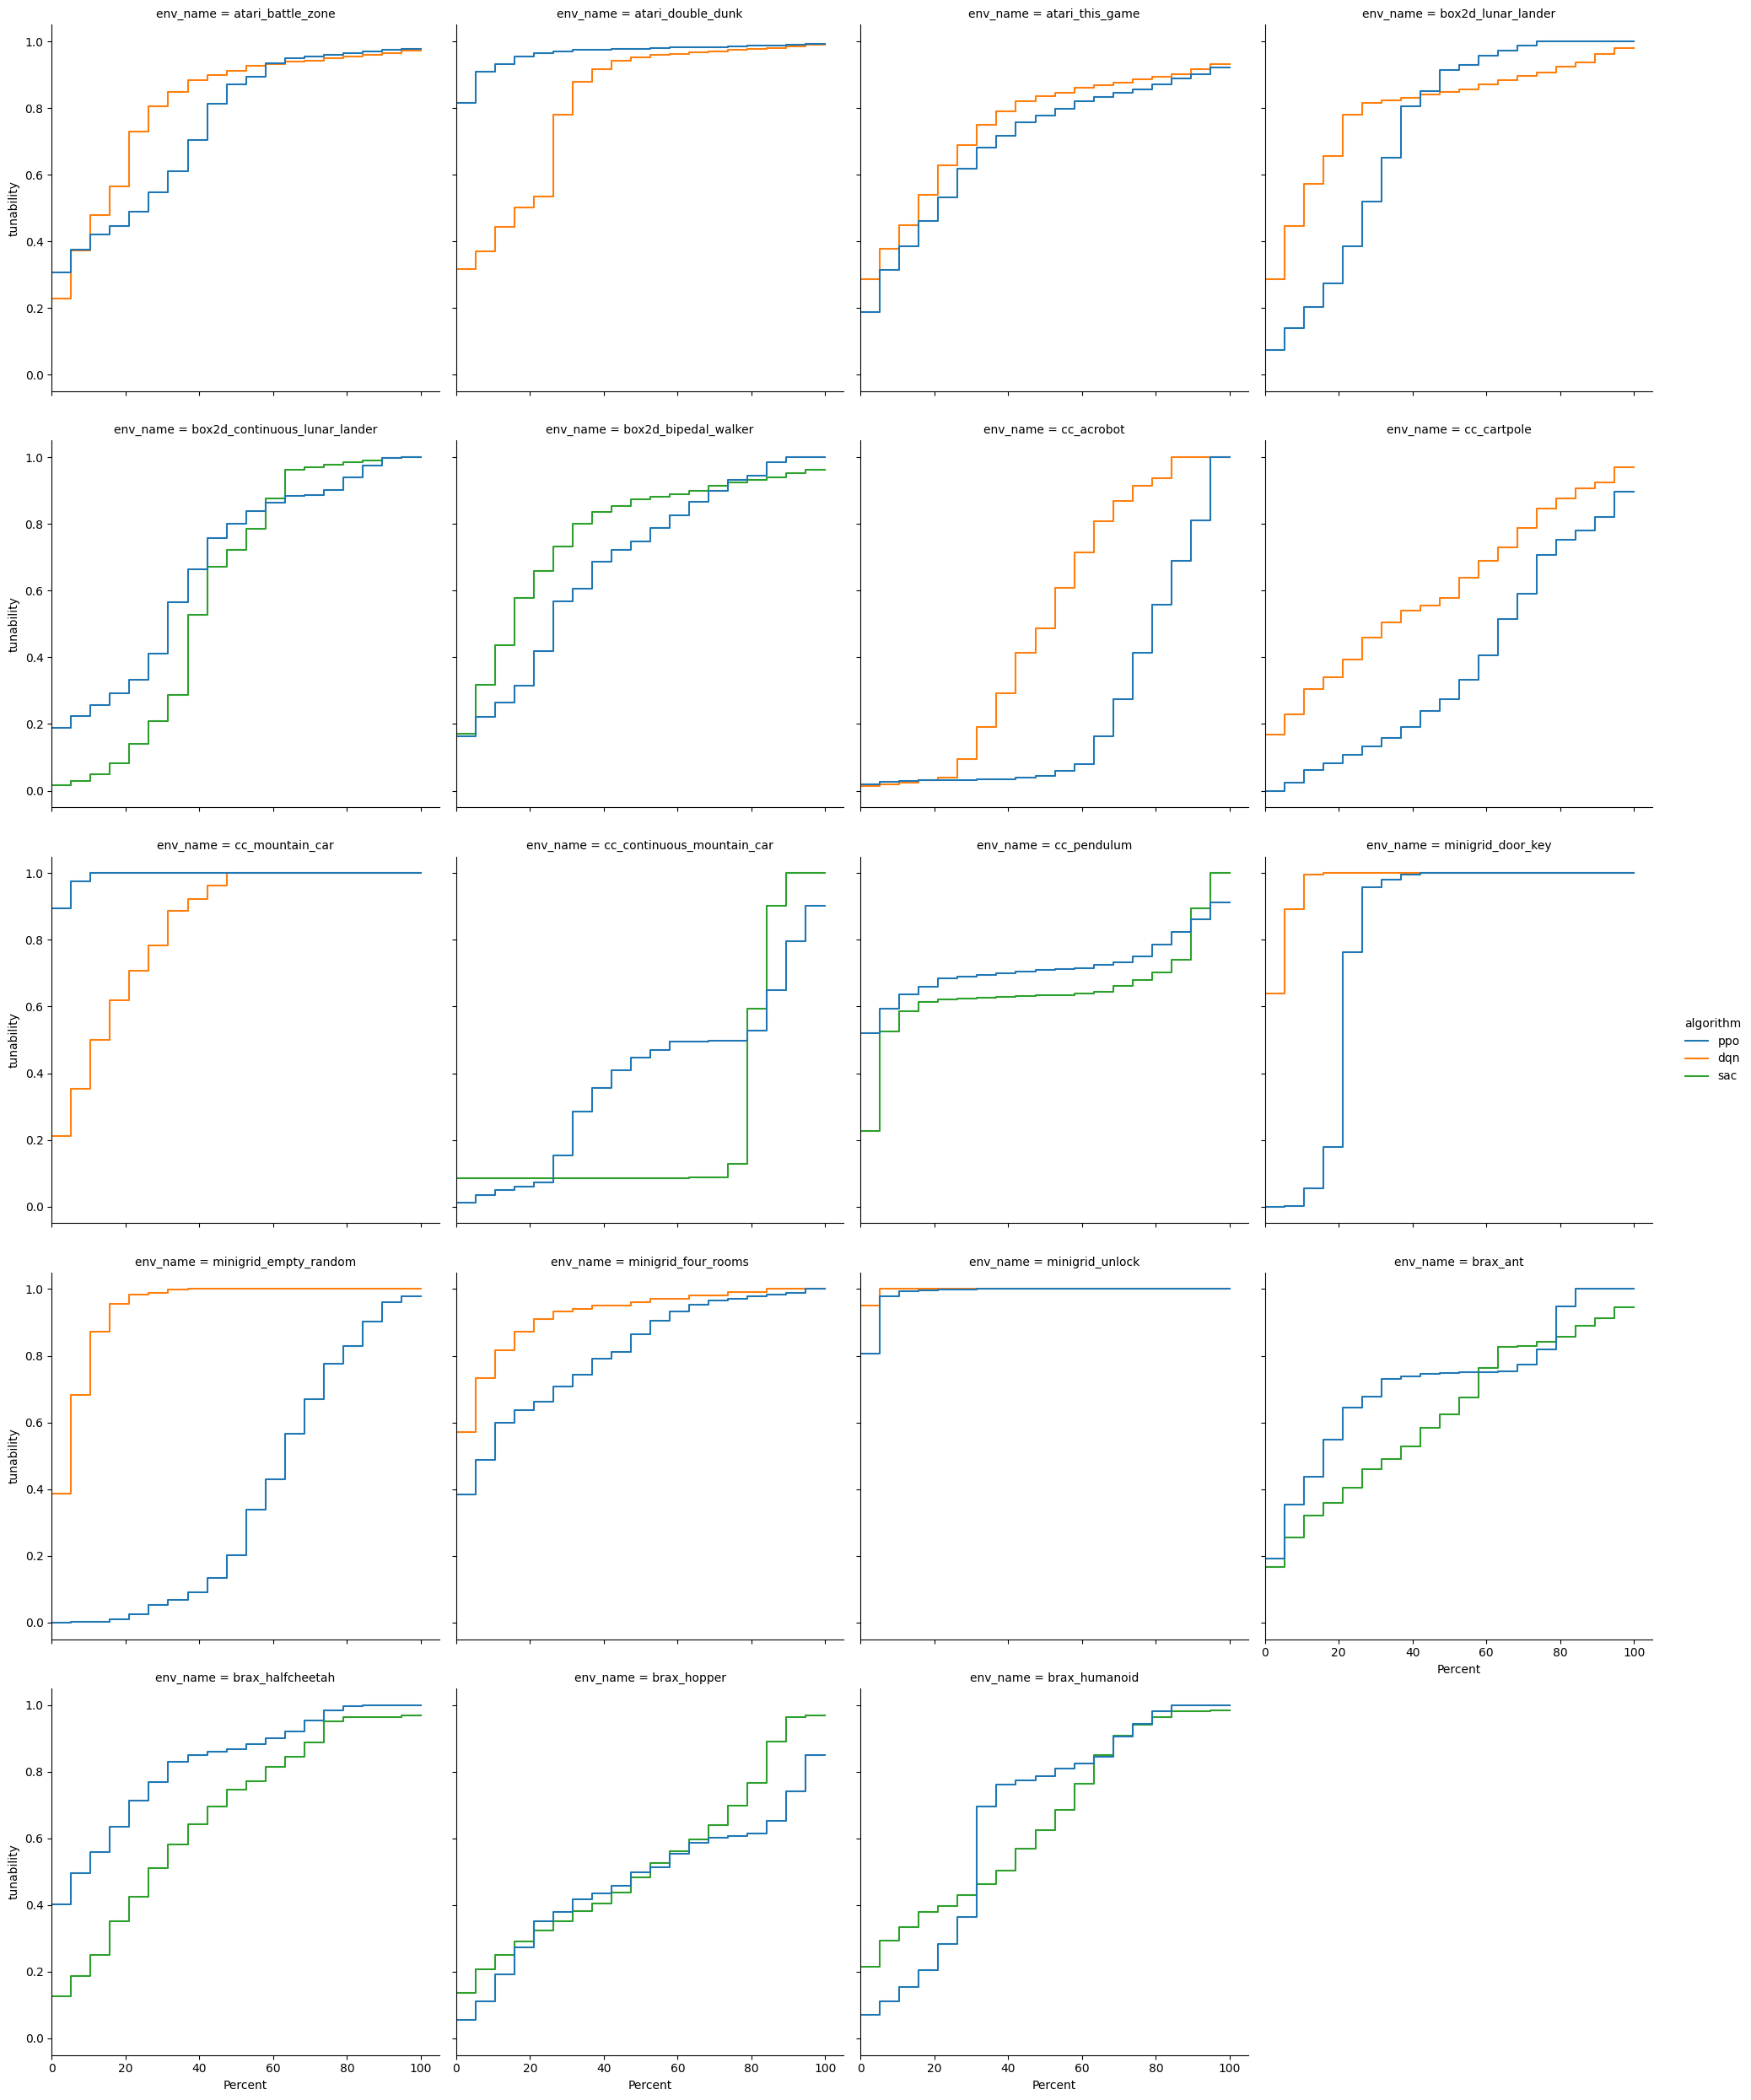

In [19]:
all_tunabilities = pd.concat([tune_05, tune_10, tune_15, tune_20, tune_25, tune_30, tune_35, tune_40, tune_45, tune_50, tune_55, tune_60, tune_65, tune_70, tune_075, tune_80, tune_85, tune_09, tune_95], keys=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]).reset_index().rename(columns={"level_0": "percentile"})
sns.displot(data=all_tunabilities, y="tunability", hue="algorithm", stat="percent", kind="ecdf", col="env_name", col_wrap=4)

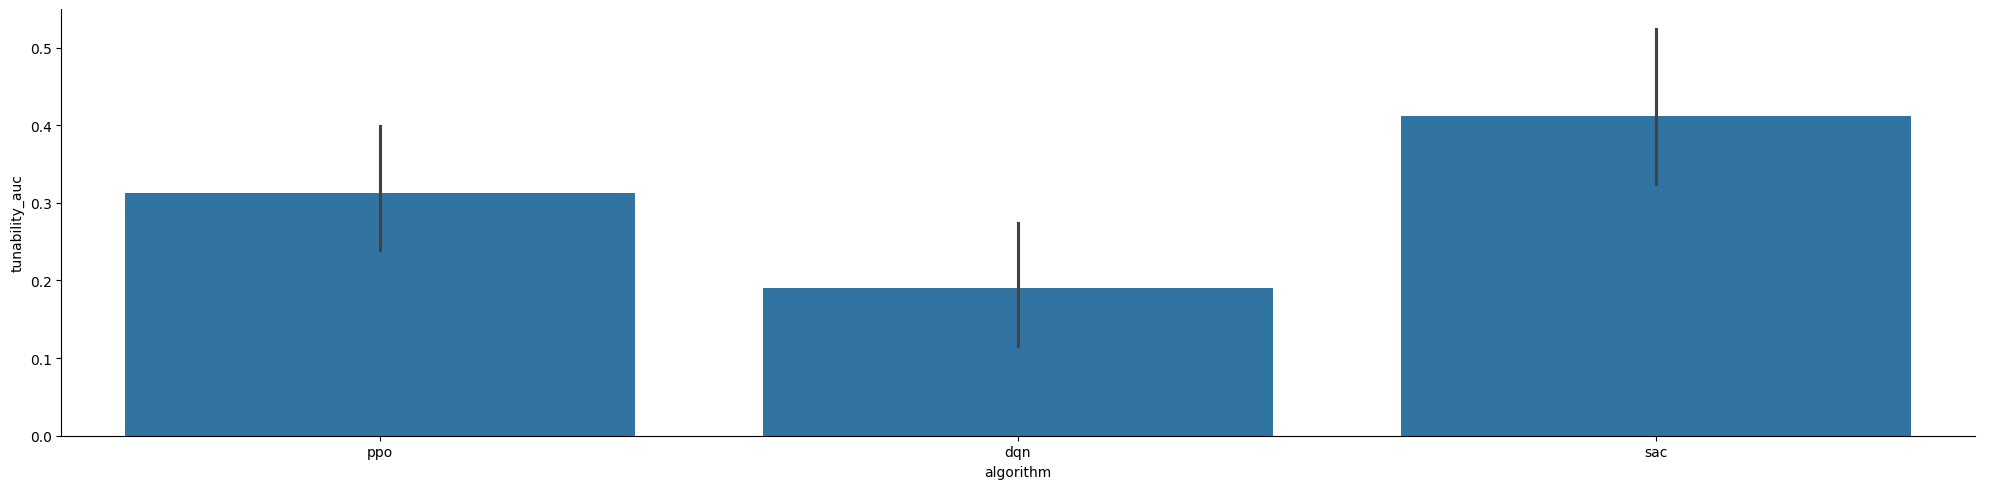

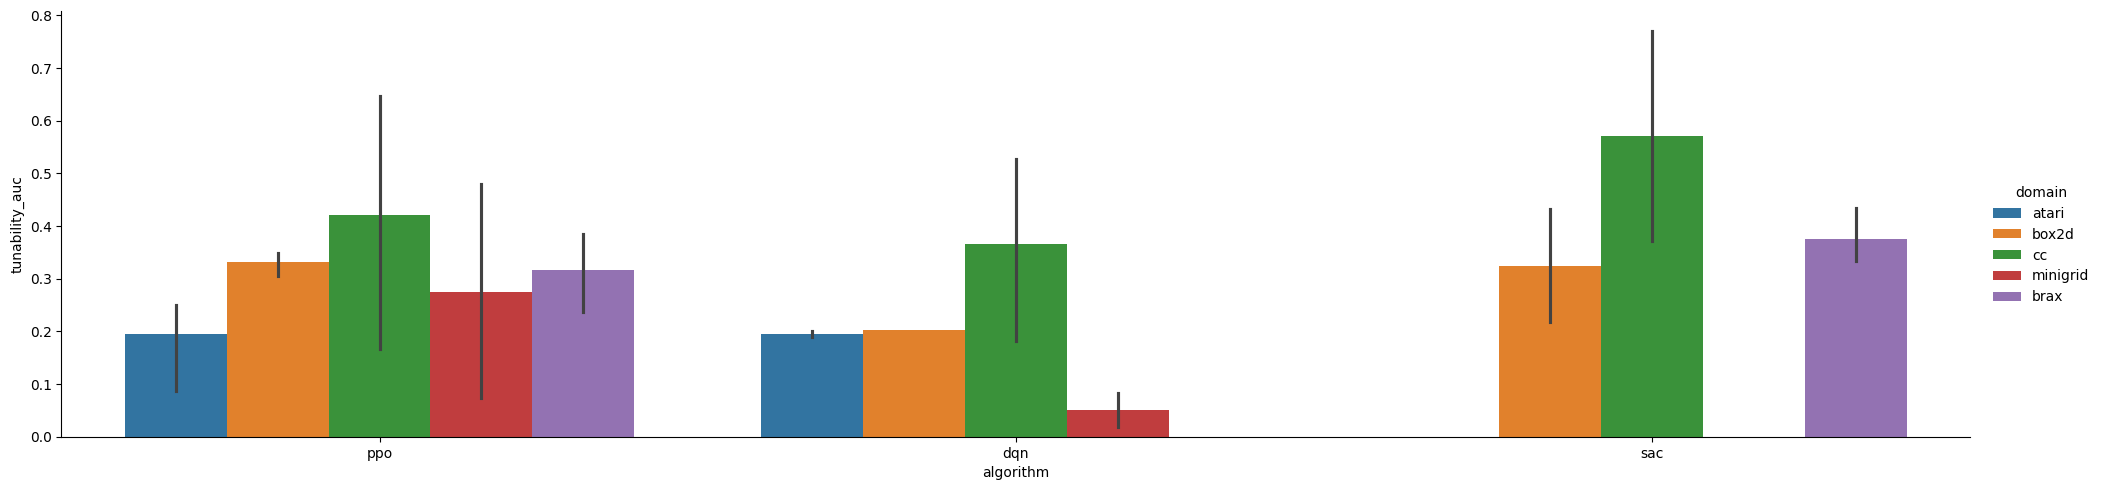

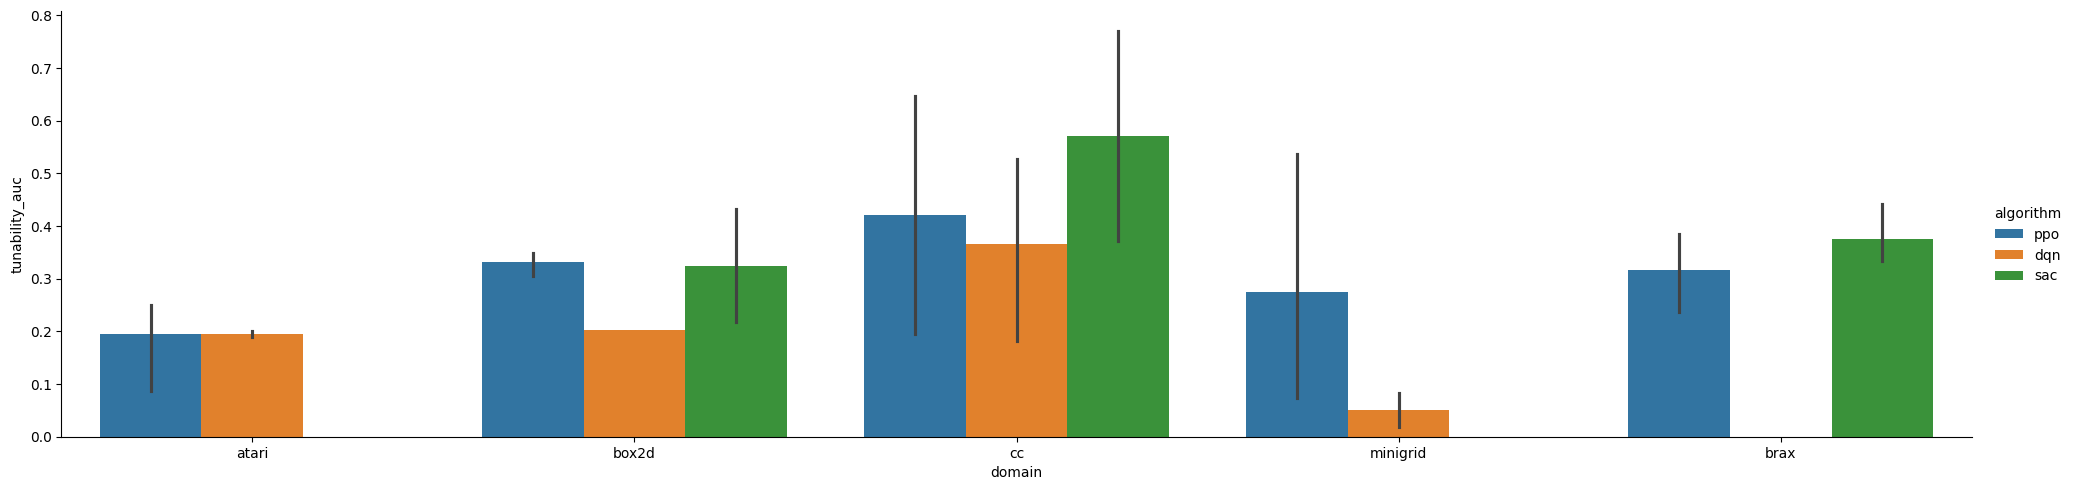

In [20]:
from sklearn.metrics import auc
from statsmodels.distributions.empirical_distribution import ECDF


aucs = []
environments = []
algorithms = []
domains = []
for algo in algos:
    for env in envs:
        subset = all_tunabilities[(all_tunabilities["algorithm"]==algo) & (all_tunabilities["env_name"]==env)]
        if subset.empty:
            continue
        sample = subset["tunability"].values
        ecdf = ECDF(sample)
        auc_value = auc(ecdf.x[1:], ecdf.y[1:])
        aucs.append(auc_value)
        environments.append(env)
        algorithms.append(algo)
        domains.append(env.split("_")[0])

tunability_auc_df = pd.DataFrame({
    "environment": environments,
    "algorithm": algorithms,
    "tunability_auc": aucs,
    "domain": domains
})
sns.catplot(data=tunability_auc_df, x="algorithm", y="tunability_auc", kind="bar", aspect=4)
sns.catplot(data=tunability_auc_df, x="algorithm", y="tunability_auc", kind="bar", aspect=4, hue="domain")
sns.catplot(data=tunability_auc_df, x="domain", y="tunability_auc", kind="bar", aspect=4, hue="algorithm")

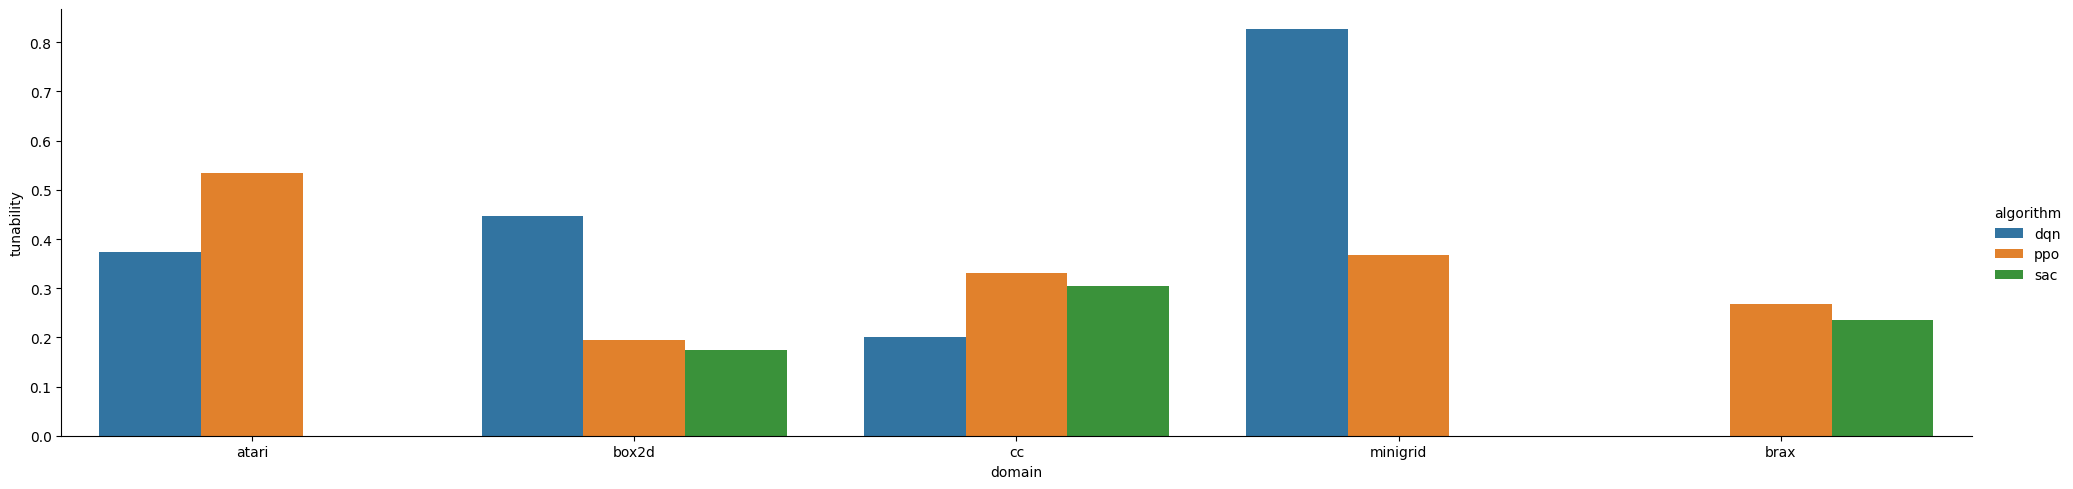

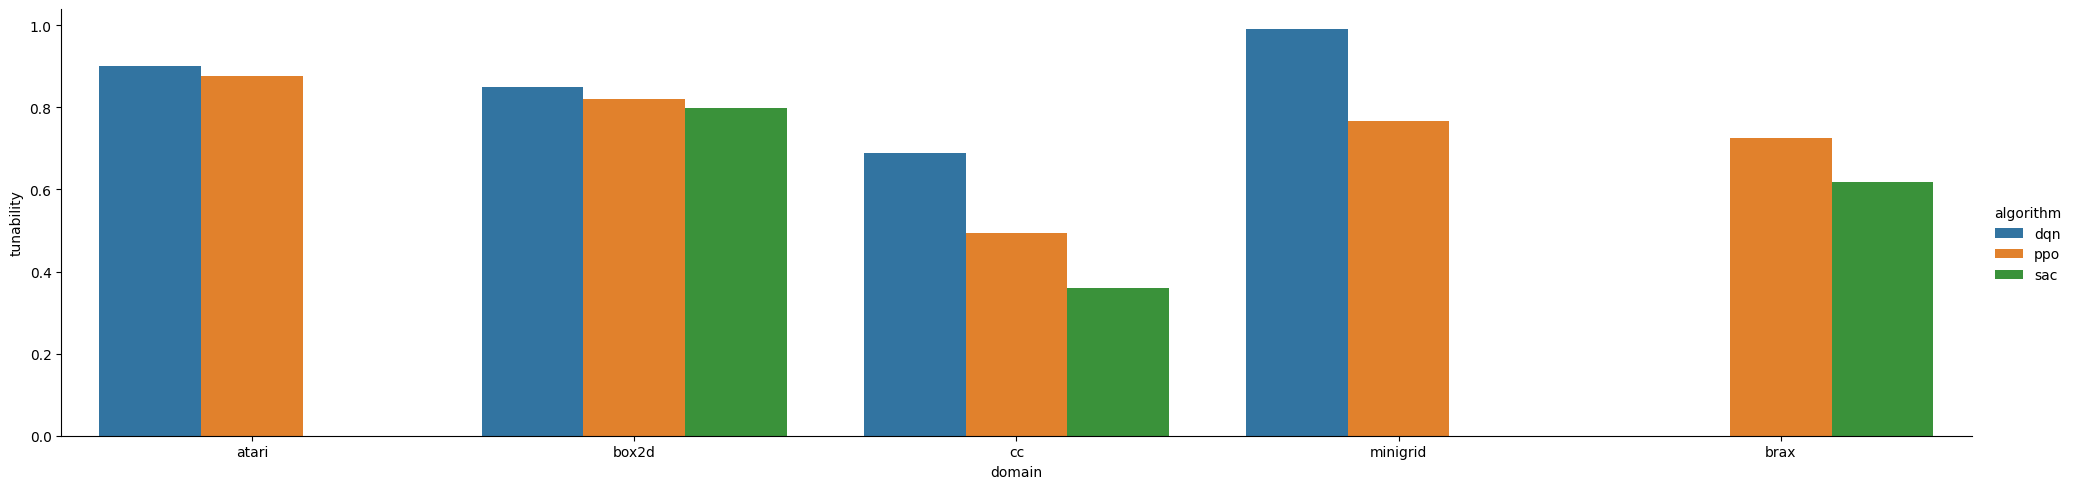

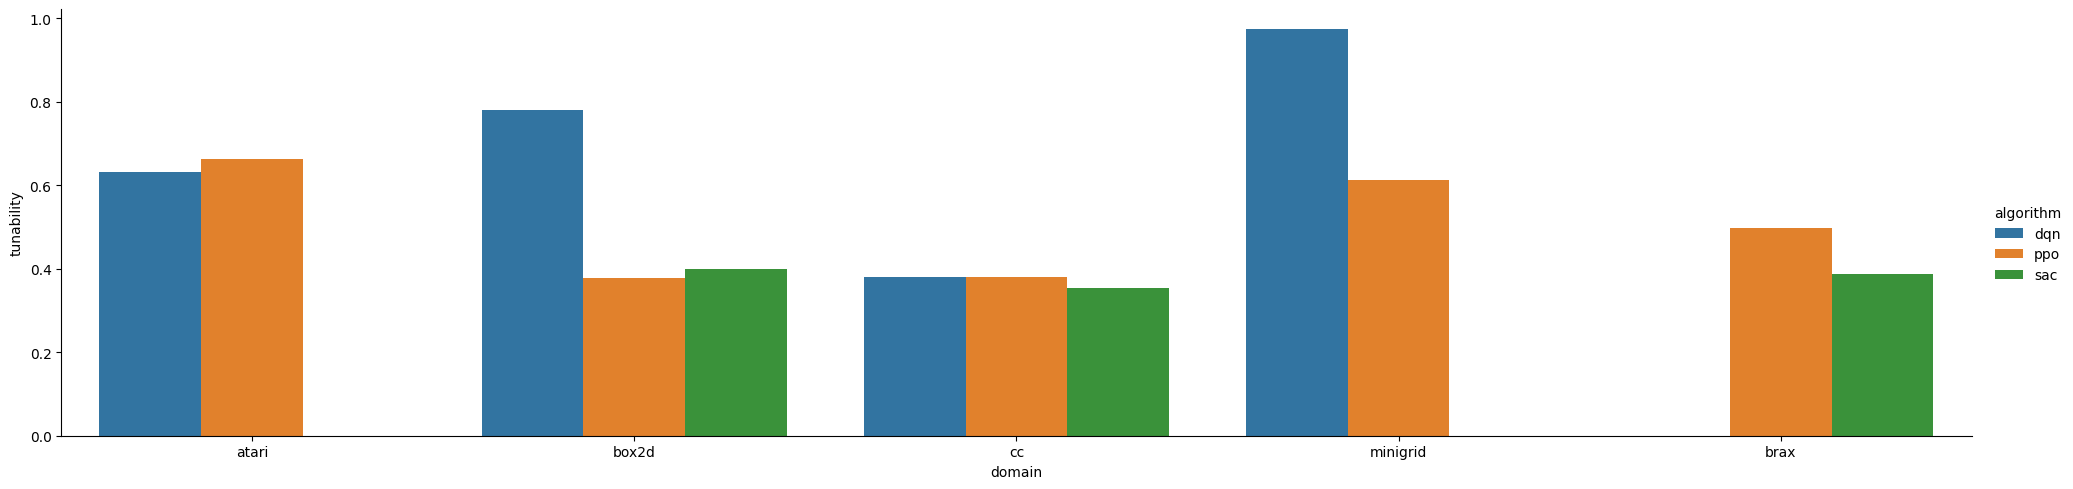

In [21]:
domains = ["atari", "box2d", "cc", "minigrid", "brax"]
per_domain_tunability_095 = []
per_domain_tunability_09 = []
per_domain_tunability_085 = []
per_domain_tunability_08 = []
per_domain_tunability_075 = []
per_domain_tunability_07 = []
per_domain_tunability_065 = []
per_domain_tunability_06 = []
per_domain_tunability_055 = []
per_domain_tunability_05 = []
per_domain_tunability_045 = []
per_domain_tunability_04 = []
per_domain_tunability_035 = []
per_domain_tunability_03 = []
per_domain_tunability_025 = []
per_domain_tunability_02 = []
per_domain_tunability_015 = []
per_domain_tunability_01 = []
per_domain_tunability_005 = []

for domain in domains:
    domain_data = tune_09[tune_09["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_09.append(mean_tunability)

    domain_data = tune_95[tune_95["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_095.append(mean_tunability)

    domain_data = tune_85[tune_85["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_085.append(mean_tunability)

    domain_data = tune_80[tune_80["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_08.append(mean_tunability)

    domain_data = tune_075[tune_075["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_075.append(mean_tunability)

    domain_data = tune_70[tune_70["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_07.append(mean_tunability)

    domain_data = tune_65[tune_65["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_065.append(mean_tunability)

    domain_data = tune_60[tune_60["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_06.append(mean_tunability)

    domain_data = tune_55[tune_55["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_055.append(mean_tunability)

    domain_data = tune_50[tune_50["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_05.append(mean_tunability)

    domain_data = tune_45[tune_45["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_045.append(mean_tunability)

    domain_data = tune_40[tune_40["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_04.append(mean_tunability)

    domain_data = tune_35[tune_35["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_035.append(mean_tunability)

    domain_data = tune_30[tune_30["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_03.append(mean_tunability)

    domain_data = tune_25[tune_25["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_025.append(mean_tunability)

    domain_data = tune_20[tune_20["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_02.append(mean_tunability)

    domain_data = tune_15[tune_15["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_015.append(mean_tunability)

    domain_data = tune_10[tune_10["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_01.append(mean_tunability)

    domain_data = tune_05[tune_05["env_name"].str.contains(domain)]
    mean_tunability = domain_data.groupby("algorithm")["tunability"].mean().reset_index()
    mean_tunability["domain"] = domain
    per_domain_tunability_005.append(mean_tunability)

per_domain_tunability_095 = pd.concat(per_domain_tunability_095)
per_domain_tunability_095.reset_index(drop=True, inplace=True)
per_domain_tunability_09 = pd.concat(per_domain_tunability_09)
per_domain_tunability_09.reset_index(drop=True, inplace=True)
per_domain_tunability_085 = pd.concat(per_domain_tunability_085)
per_domain_tunability_085.reset_index(drop=True, inplace=True)
per_domain_tunability_08 = pd.concat(per_domain_tunability_08)
per_domain_tunability_08.reset_index(drop=True, inplace=True)
per_domain_tunability_075 = pd.concat(per_domain_tunability_075)
per_domain_tunability_075.reset_index(drop=True, inplace=True)
per_domain_tunability_07 = pd.concat(per_domain_tunability_07)
per_domain_tunability_07.reset_index(drop=True, inplace=True)
per_domain_tunability_065 = pd.concat(per_domain_tunability_065)
per_domain_tunability_065.reset_index(drop=True, inplace=True)
per_domain_tunability_06 = pd.concat(per_domain_tunability_06)
per_domain_tunability_06.reset_index(drop=True, inplace=True)
per_domain_tunability_055 = pd.concat(per_domain_tunability_055)
per_domain_tunability_055.reset_index(drop=True, inplace=True)
per_domain_tunability_05 = pd.concat(per_domain_tunability_05)
per_domain_tunability_05.reset_index(drop=True, inplace=True)
per_domain_tunability_045 = pd.concat(per_domain_tunability_045)
per_domain_tunability_045.reset_index(drop=True, inplace=True)
per_domain_tunability_04 = pd.concat(per_domain_tunability_04)
per_domain_tunability_04.reset_index(drop=True, inplace=True)
per_domain_tunability_035 = pd.concat(per_domain_tunability_035)
per_domain_tunability_035.reset_index(drop=True, inplace=True)
per_domain_tunability_03 = pd.concat(per_domain_tunability_03)
per_domain_tunability_03.reset_index(drop=True, inplace=True)
per_domain_tunability_025 = pd.concat(per_domain_tunability_025)
per_domain_tunability_025.reset_index(drop=True, inplace=True)
per_domain_tunability_02 = pd.concat(per_domain_tunability_02)  
per_domain_tunability_02.reset_index(drop=True, inplace=True)
per_domain_tunability_015 = pd.concat(per_domain_tunability_015)
per_domain_tunability_015.reset_index(drop=True, inplace=True)
per_domain_tunability_01 = pd.concat(per_domain_tunability_01)
per_domain_tunability_01.reset_index(drop=True, inplace=True)
per_domain_tunability_005 = pd.concat(per_domain_tunability_005)
per_domain_tunability_005.reset_index(drop=True, inplace=True)

sns.catplot(data=per_domain_tunability_09, x="domain", y="tunability", hue="algorithm", kind="bar", aspect=4)
sns.catplot(data=per_domain_tunability_05, x="domain", y="tunability", hue="algorithm", kind="bar", aspect=4)
sns.catplot(data=per_domain_tunability_075, x="domain", y="tunability", hue="algorithm", kind="bar", aspect=4)

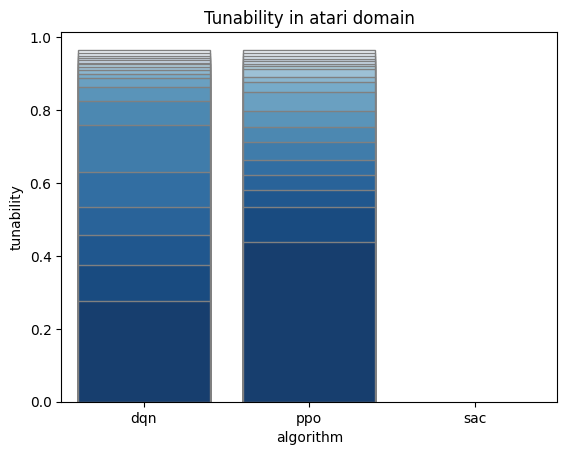

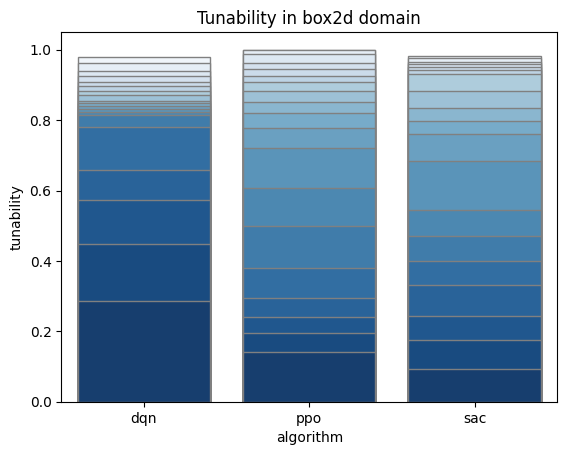

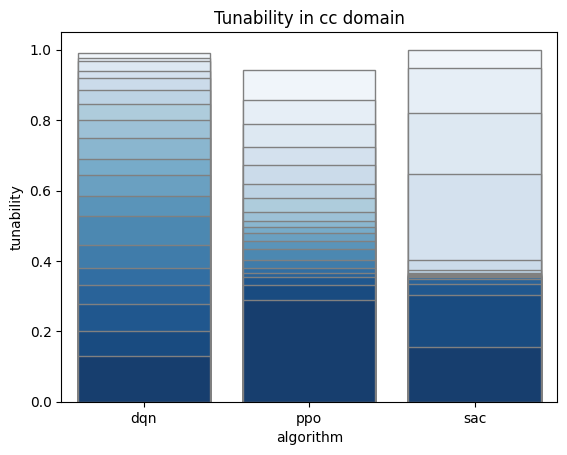

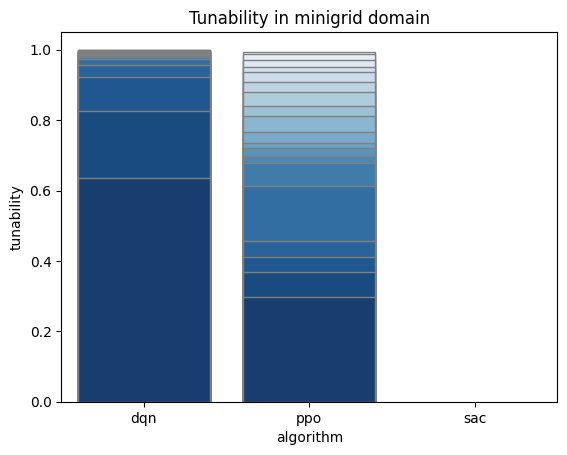

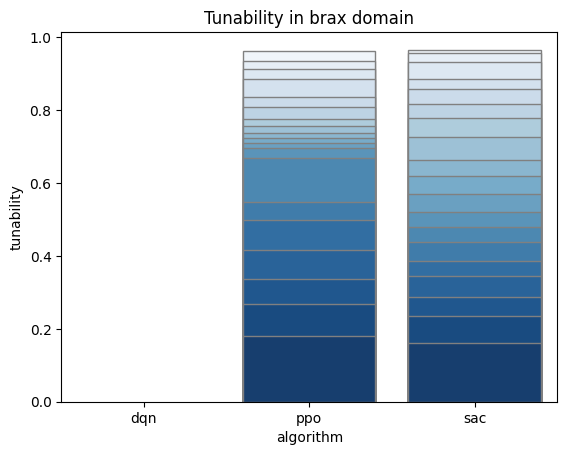

In [22]:
for domain in domains:
    sns.barplot(data=per_domain_tunability_005[per_domain_tunability_005["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[0])
    sns.barplot(data=per_domain_tunability_01[per_domain_tunability_01["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[1])
    sns.barplot(data=per_domain_tunability_015[per_domain_tunability_015["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[2])
    sns.barplot(data=per_domain_tunability_02[per_domain_tunability_02["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[3])
    sns.barplot(data=per_domain_tunability_025[per_domain_tunability_025["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[4])
    sns.barplot(data=per_domain_tunability_03[per_domain_tunability_03["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[5])
    sns.barplot(data=per_domain_tunability_035[per_domain_tunability_035["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[6])
    sns.barplot(data=per_domain_tunability_04[per_domain_tunability_04["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[7])
    sns.barplot(data=per_domain_tunability_045[per_domain_tunability_045["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[8])
    sns.barplot(data=per_domain_tunability_05[per_domain_tunability_05["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[9])
    sns.barplot(data=per_domain_tunability_055[per_domain_tunability_055["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[10])
    sns.barplot(data=per_domain_tunability_06[per_domain_tunability_06["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[11])
    sns.barplot(data=per_domain_tunability_065[per_domain_tunability_065["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[12])
    sns.barplot(data=per_domain_tunability_07[per_domain_tunability_07["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[13])
    sns.barplot(data=per_domain_tunability_075[per_domain_tunability_075["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[14])
    sns.barplot(data=per_domain_tunability_08[per_domain_tunability_08["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[15])
    sns.barplot(data=per_domain_tunability_085[per_domain_tunability_085["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[16])
    sns.barplot(data=per_domain_tunability_09[per_domain_tunability_09["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[17])
    sns.barplot(data=per_domain_tunability_095[per_domain_tunability_095["domain"]==domain], x="algorithm", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[18])
    plt.title(f"Tunability in {domain} domain")
    plt.show()

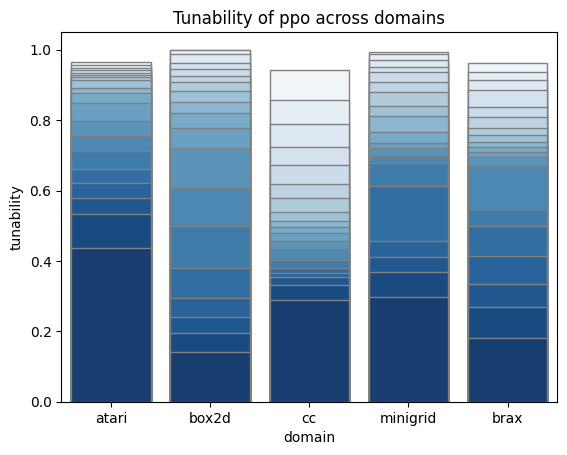

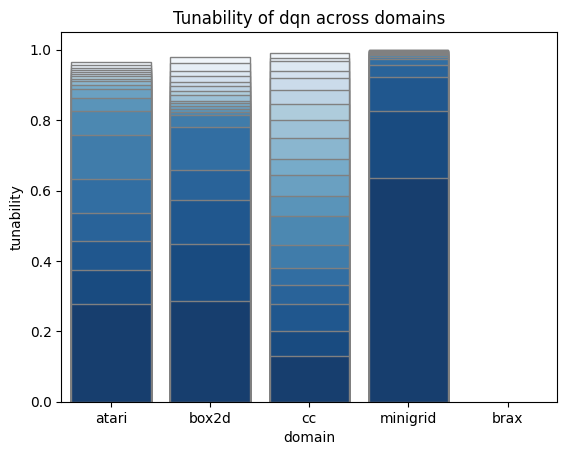

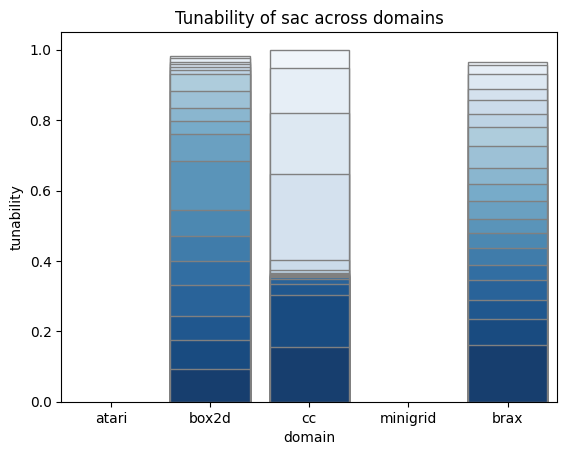

In [23]:
for algo in algos:
    sns.barplot(data=per_domain_tunability_005[per_domain_tunability_005["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[0])
    sns.barplot(data=per_domain_tunability_01[per_domain_tunability_01["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[1])
    sns.barplot(data=per_domain_tunability_015[per_domain_tunability_015["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[2])
    sns.barplot(data=per_domain_tunability_02[per_domain_tunability_02["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[3])
    sns.barplot(data=per_domain_tunability_025[per_domain_tunability_025["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[4])
    sns.barplot(data=per_domain_tunability_03[per_domain_tunability_03["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[5])
    sns.barplot(data=per_domain_tunability_035[per_domain_tunability_035["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[6])
    sns.barplot(data=per_domain_tunability_04[per_domain_tunability_04["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[7])
    sns.barplot(data=per_domain_tunability_045[per_domain_tunability_045["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[8])
    sns.barplot(data=per_domain_tunability_05[per_domain_tunability_05["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[9])
    sns.barplot(data=per_domain_tunability_055[per_domain_tunability_055["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[10])
    sns.barplot(data=per_domain_tunability_06[per_domain_tunability_06["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[11])
    sns.barplot(data=per_domain_tunability_065[per_domain_tunability_065["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[12])
    sns.barplot(data=per_domain_tunability_07[per_domain_tunability_07["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[13])
    sns.barplot(data=per_domain_tunability_075[per_domain_tunability_075["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[14])
    sns.barplot(data=per_domain_tunability_08[per_domain_tunability_08["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[15])
    sns.barplot(data=per_domain_tunability_085[per_domain_tunability_085["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[16])
    sns.barplot(data=per_domain_tunability_09[per_domain_tunability_09["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[17])
    sns.barplot(data=per_domain_tunability_095[per_domain_tunability_095["algorithm"]==algo], x="domain", y="tunability", edgecolor=".5", color=sns.color_palette("Blues", 19).as_hex()[18])
    plt.title(f"Tunability of {algo} across domains")
    plt.show()

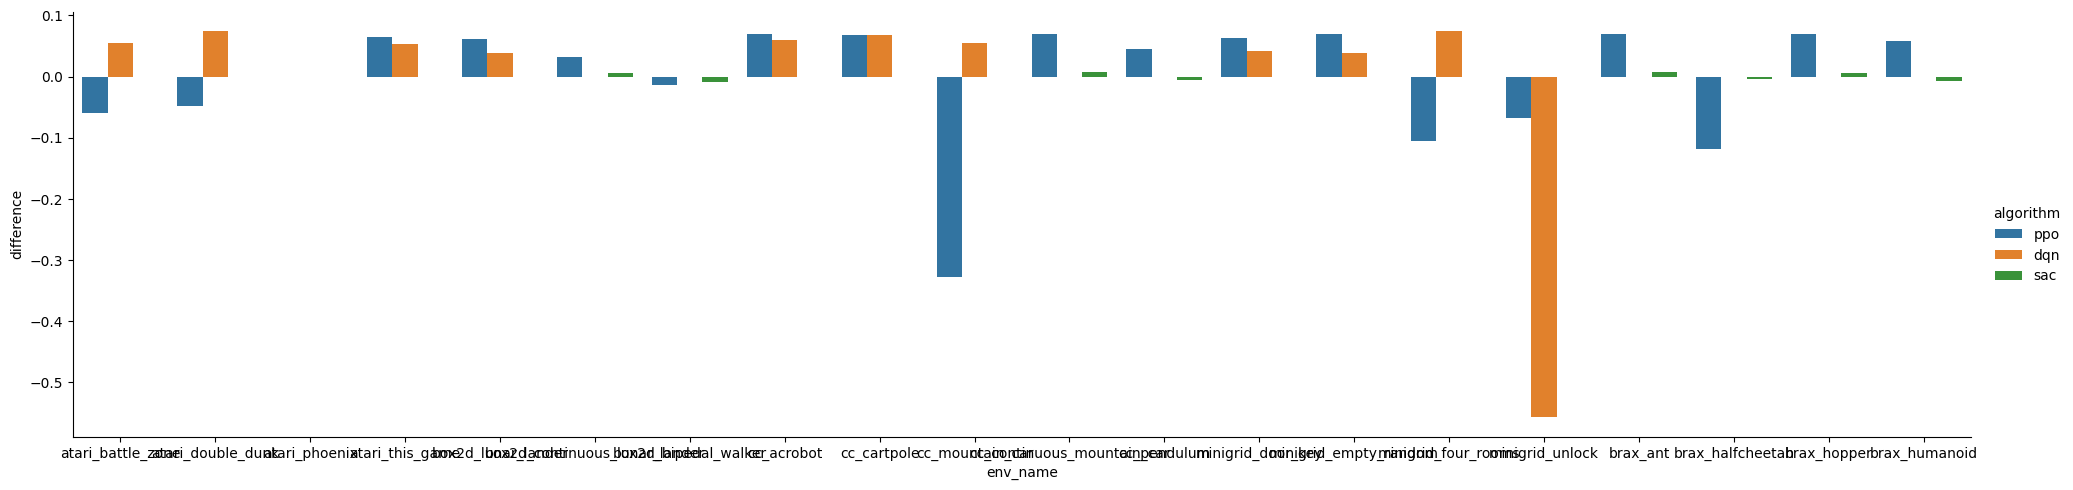

In [24]:
per_env_vs_cross_env_max = []
for algo in algos:
    for env in envs:
        subset = data[data["algorithm"]==algo]
        percentile05 = subset["last_performance"].quantile(0.05)
        percentile95 = subset["last_performance"].quantile(0.95)
        subset = subset[(subset["last_performance"]>=percentile05) & (subset["last_performance"]<=percentile95)]
        cross_env_max = subset.groupby("env_name")["last_performance"].max().mean()
        env_subset = subset[subset["env_name"]==env]
        env_max = env_subset["last_performance"].max()
        difference = env_max - cross_env_max
        per_env_vs_cross_env_max.append({
            "algorithm": algo,
            "env_name": env,
            "env_max": env_max,
            "cross_env_max": cross_env_max,
            "difference": difference
        })
per_env_vs_cross_env_max = pd.DataFrame(per_env_vs_cross_env_max)
sns.catplot(data=per_env_vs_cross_env_max, x="env_name", y="difference", hue="algorithm", kind="bar", aspect=4)

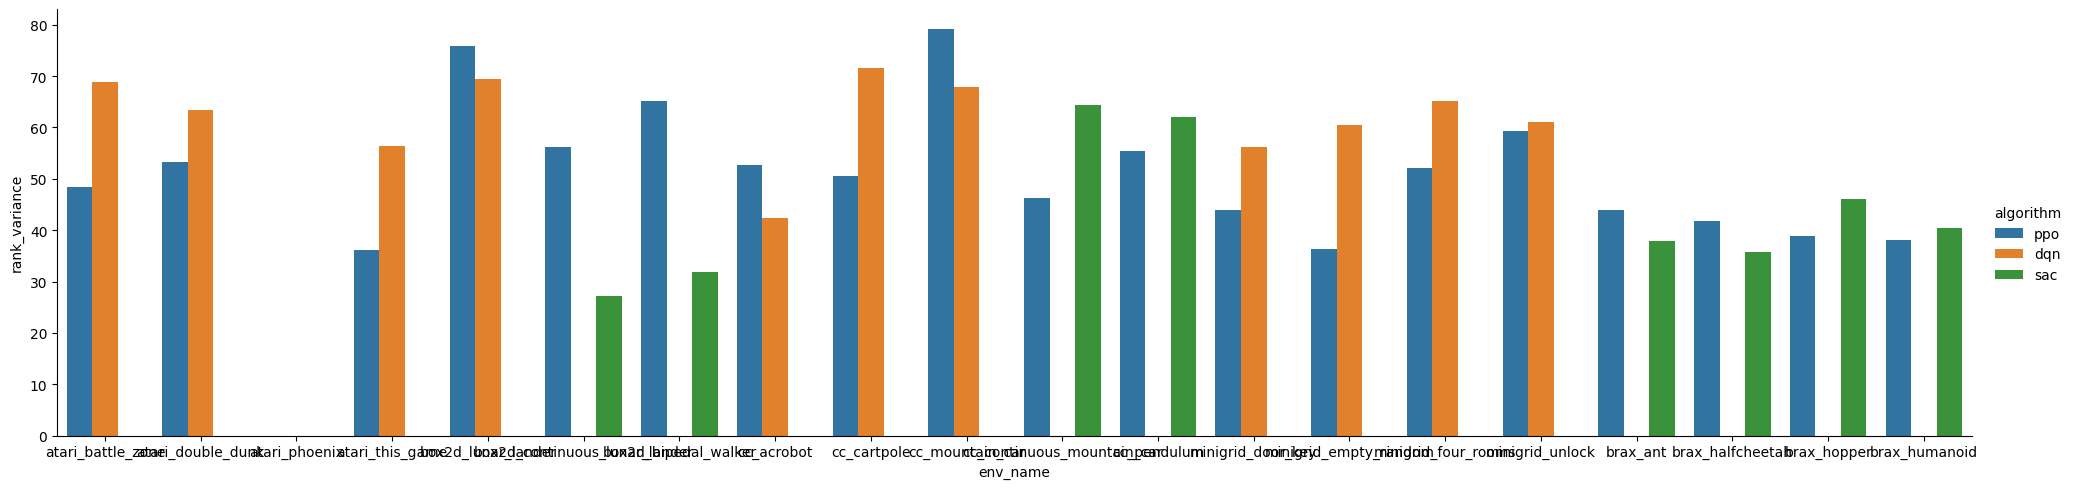

In [25]:
# rank consistency analysis
rank_consistency = []
for env in envs:
    for algo in algos:
        subset = data[data["algorithm"]==algo]
        overall_ranked = subset.groupby("config_id")["last_performance"].mean()
        env_subset = subset[subset["env_name"]==env]
        env_subset = env_subset.groupby("config_id")["last_performance"].mean()
        overall_ranked["rank"] = overall_ranked.rank(ascending=False)
        env_subset["rank"] = env_subset.rank(ascending=False)
        rank_diff = overall_ranked["rank"] - env_subset["rank"]
        abs_rank_diff = rank_diff.abs()
        rank_variance = abs_rank_diff.mean()
        rank_consistency.append({
            "env_name": env,
            "algorithm": algo,
            "rank_variance": rank_variance
        })
rank_consistency = pd.DataFrame(rank_consistency)
sns.catplot(data=rank_consistency, x="env_name", y="rank_variance", hue="algorithm", kind="bar", aspect=4)

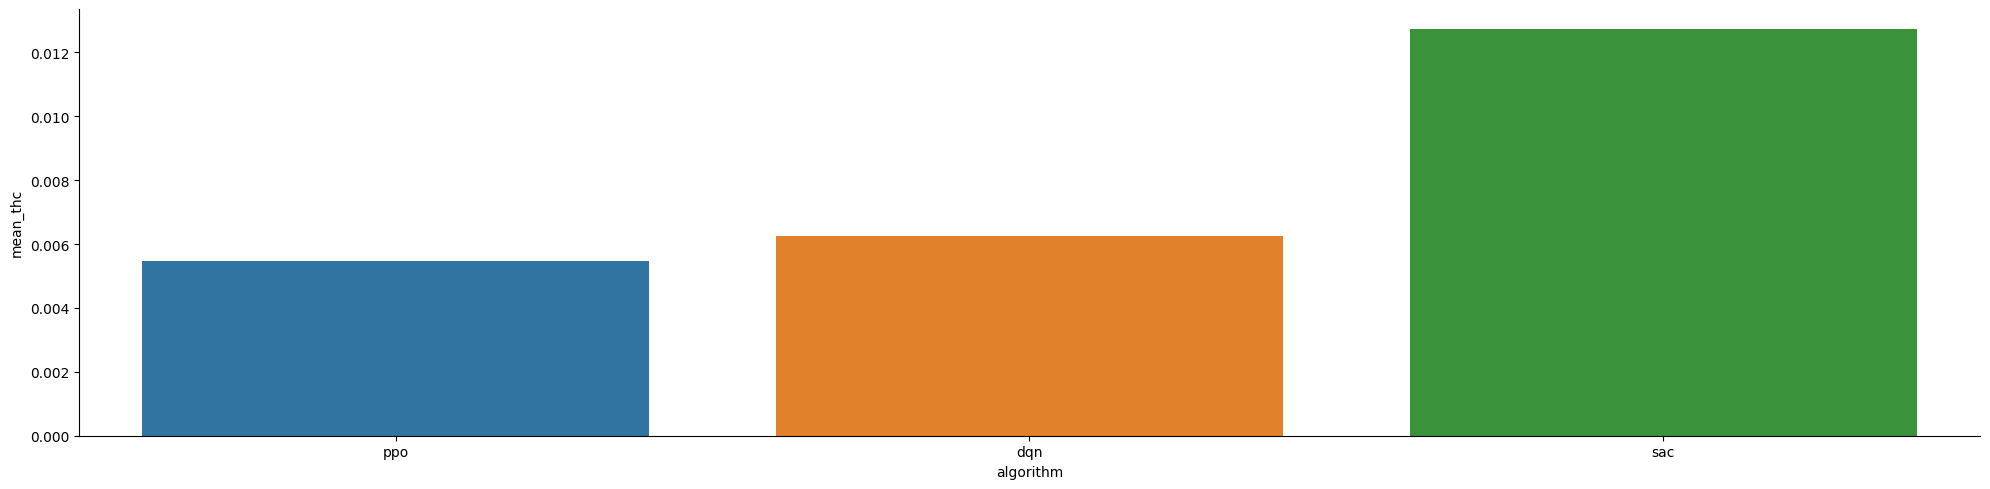

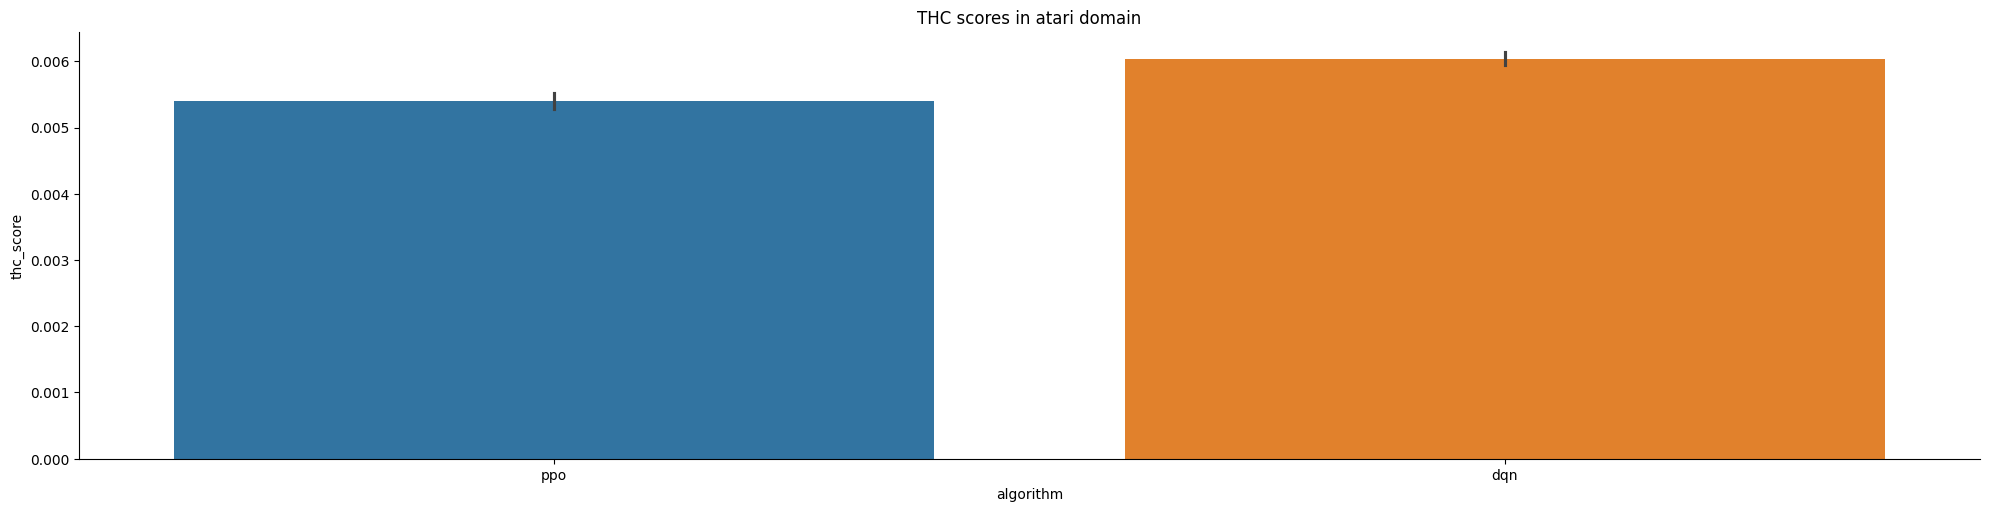

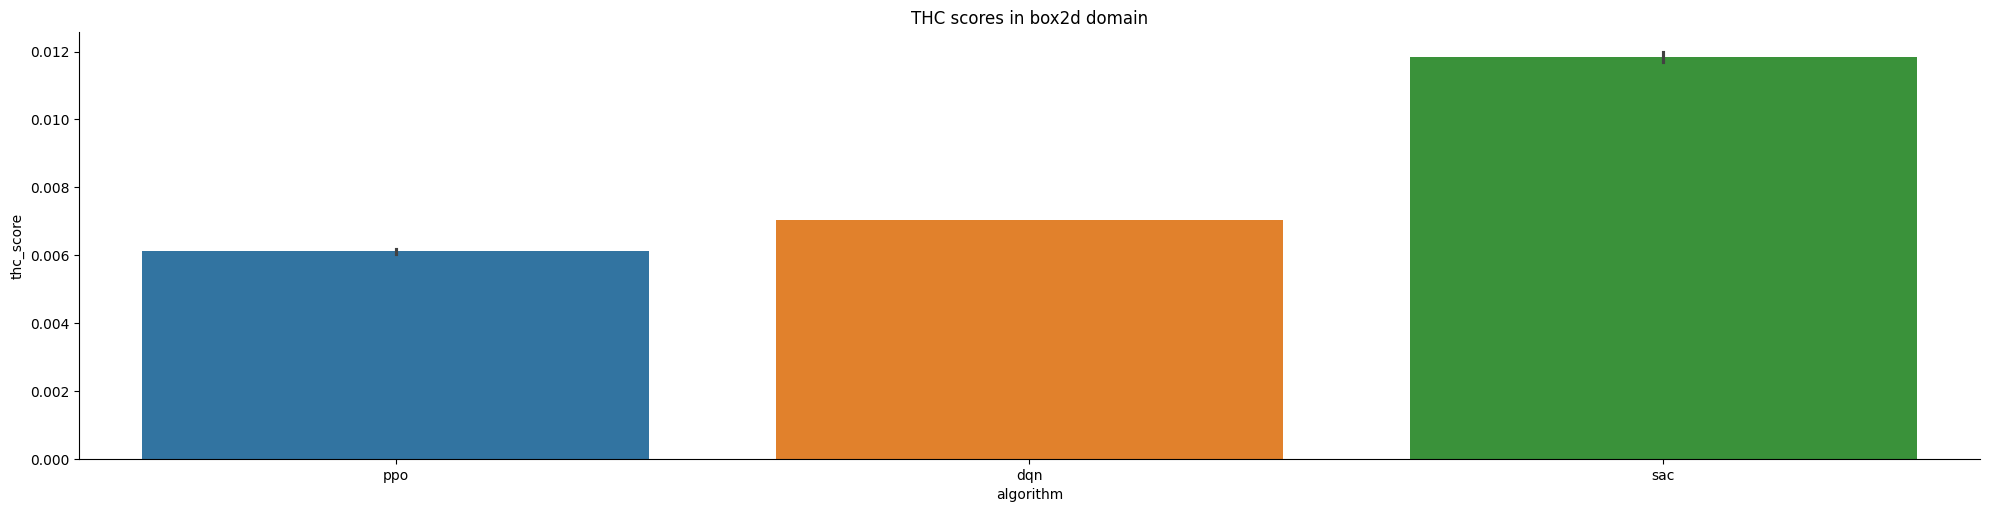

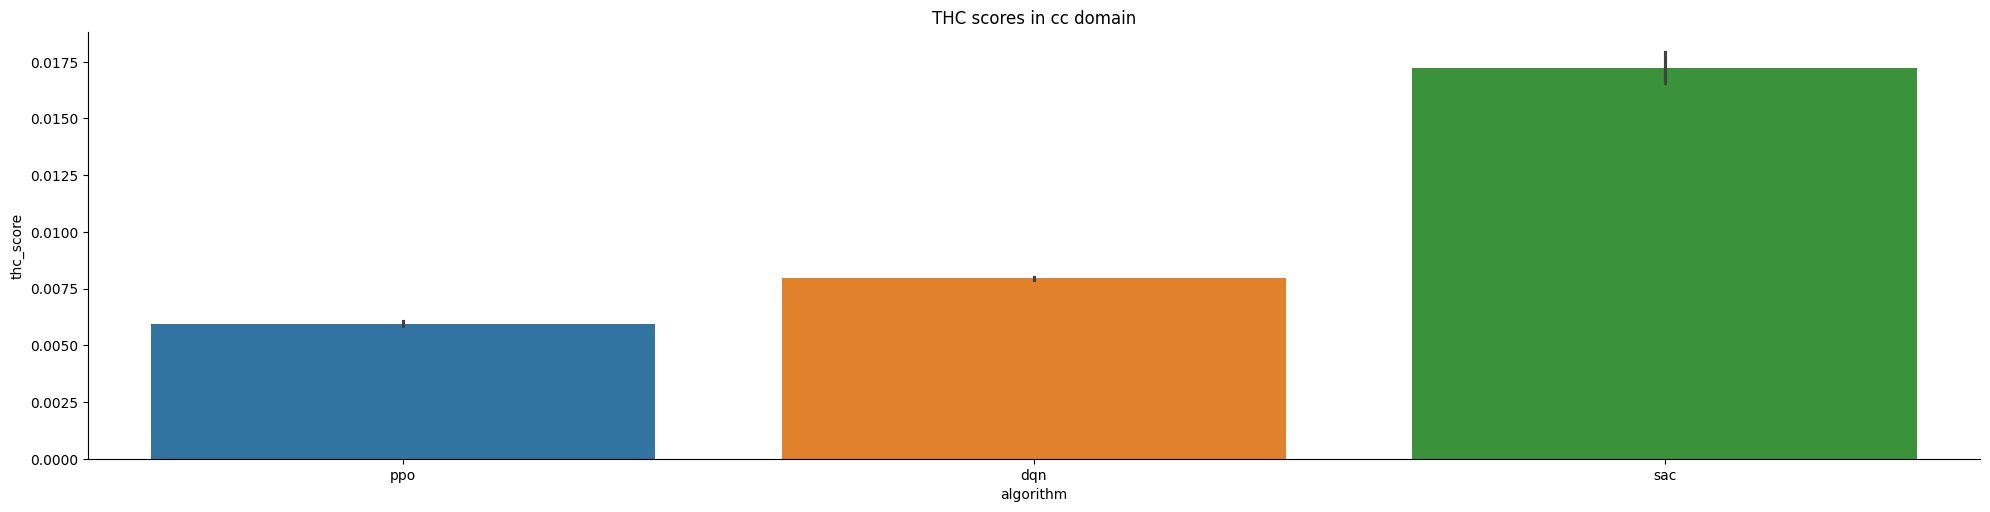

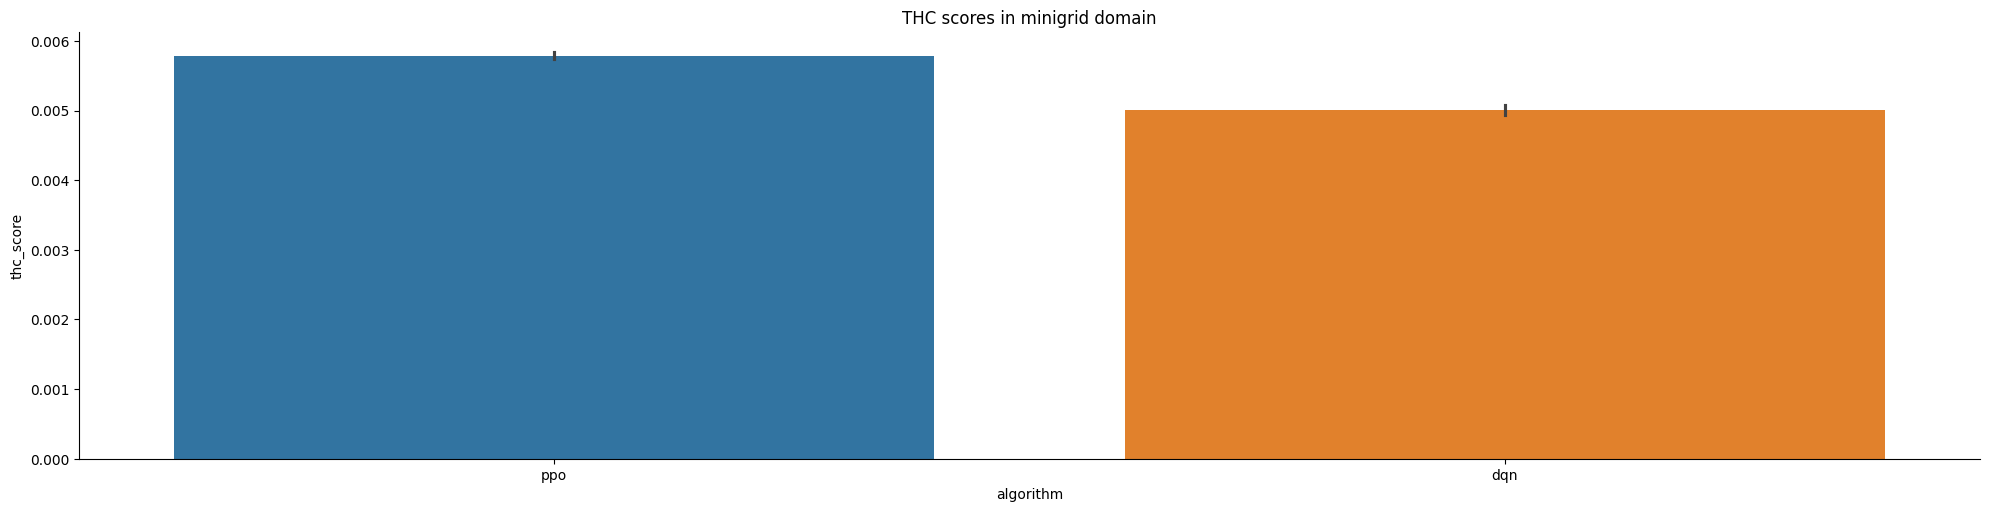

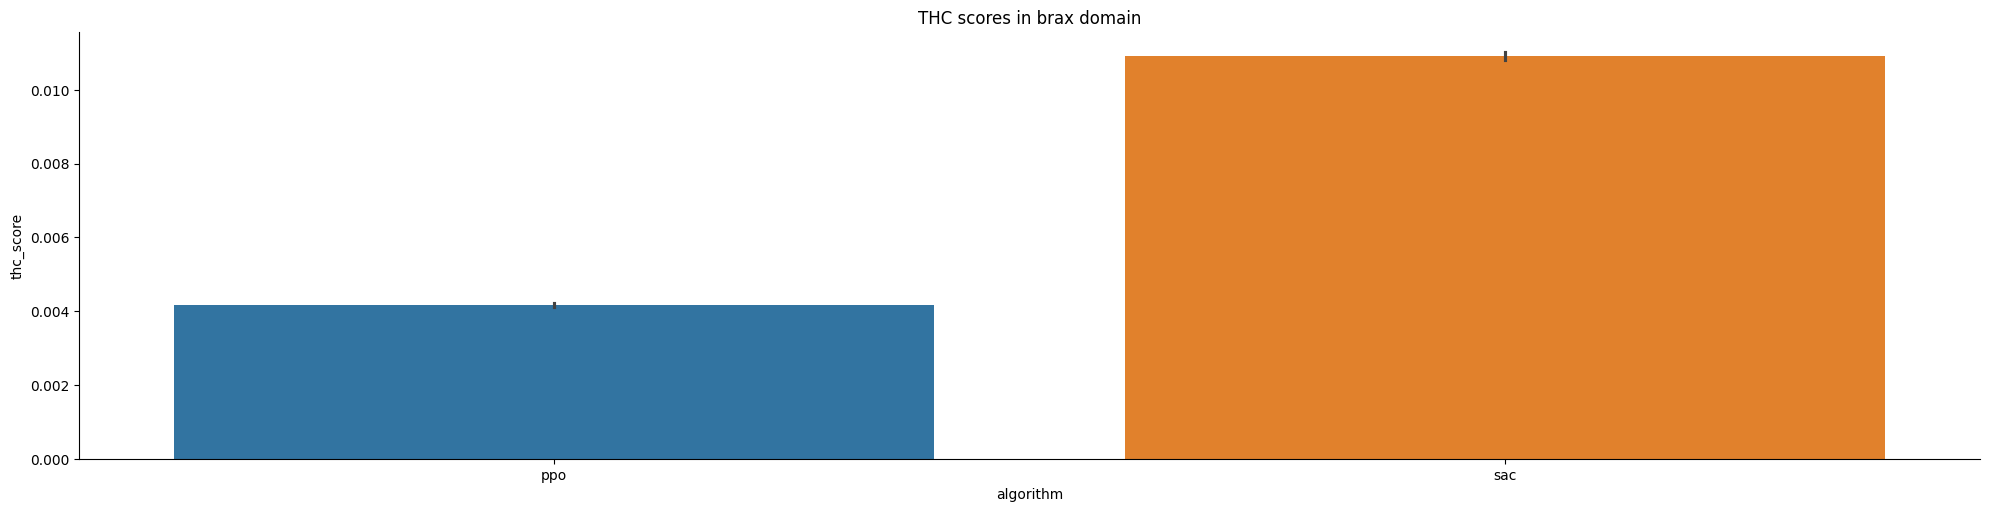

In [26]:
# THC metric
ranks = []
config_ids = []
environments = []
algorithms = []
for env in envs:
    for algo in algos:
        subset = data[data["algorithm"]==algo]
        env_subset = subset[subset["env_name"]==env]
        if len(env_subset) == 0:
            continue
        mu = env_subset.groupby("config_id")["last_performance"].mean()
        sigma = env_subset.groupby("config_id")["last_performance"].std(ddof=0)
        
        def binary_search_upper(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] > target:
                    high = mid
                else:
                    low = mid + 1
            return low - 1

        def binary_search_lower(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] < target:
                    low = mid + 1
                else:
                    high = mid
            return low

        r_prime = np.argsort(mu + sigma)[::-1]  # Descending order (higher is better)
        mu_prime = mu.iloc[r_prime]
        sigma_prime = sigma.iloc[r_prime]
        lower_bounds = mu_prime - sigma_prime
        upper_bounds = mu_prime + sigma_prime
            
        for config_id in subset["config_id"].unique():
            upper_bound_j = mu[config_id] + sigma[config_id]
            u = binary_search_upper(lower_bounds, upper_bound_j)

            lower_bound_j = mu[config_id] - sigma[config_id]
            l = binary_search_lower(upper_bounds, lower_bound_j)
            config_ids.append(config_id)
            ranks.append((u + l) / 2.0)
            environments.append(env)
            algorithms.append(algo)

thc_data = pd.DataFrame({
    "env_name": environments,
    "algorithm": algorithms,
    "config_id": config_ids,
    "thc_rank": ranks
})
thc_data["ptp"] = thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform(lambda x: x.max() - x.min())
thc_data["normed_ptp"] = thc_data["ptp"] / thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform("sum")
thc_data["thc_score"] = thc_data.groupby(["env_name", "algorithm"])["normed_ptp"].transform("mean")
thc_data["mean_thc"] = thc_data.groupby(["algorithm"])["thc_score"].transform("mean")
sns.catplot(data=thc_data, x="algorithm", y="mean_thc", hue="algorithm", kind="bar", aspect=4)
for domain in domains:
    domain_thc = thc_data[thc_data["env_name"].str.contains(domain)]
    sns.catplot(data=domain_thc, x="algorithm", y="thc_score", hue="algorithm", kind="bar", aspect=4)
    plt.title(f"THC scores in {domain} domain")

In [27]:
print(thc_data.groupby("algorithm")["thc_score"].mean())

algorithm
dqn    0.006256
ppo    0.005478
sac    0.012725
Name: thc_score, dtype: float64
